In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")

df= pd.read_csv('/content/traffic_accidents.csv')
print('----------Traffic Accident Data----------')
display(df.head())

----------Traffic Accident Data----------


,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY


In [3]:
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Number of rows: 209306
Number of columns: 10


In [4]:
# Find the missing value
print('----------Missing Value----------')
print(df.isnull().sum()[df.isnull().sum() > 0])

----------Missing Value----------
Series([], dtype: int64)


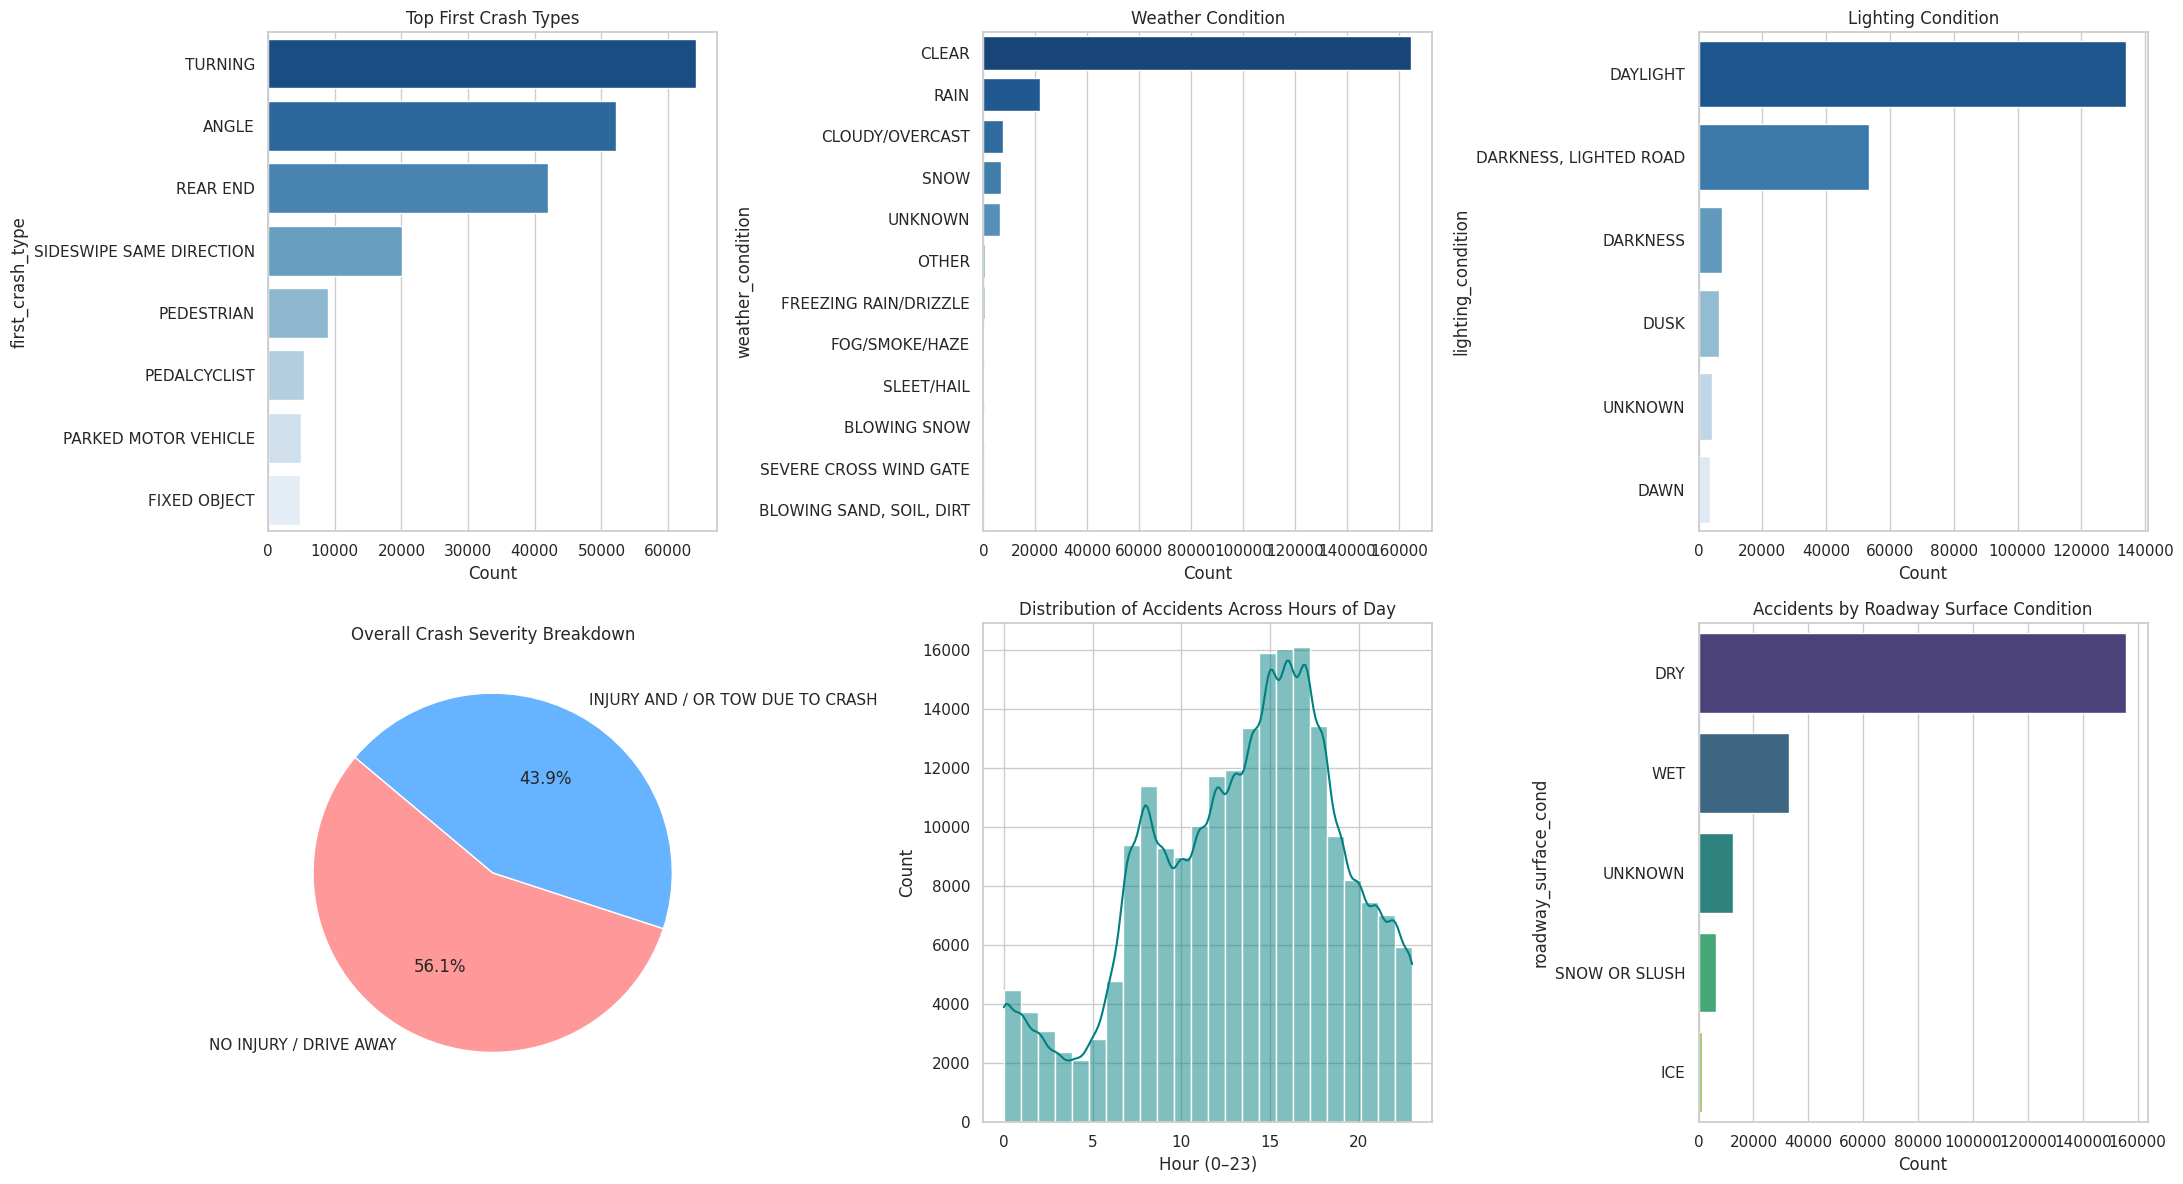

In [5]:
# Univariable analysis
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
plt.subplots_adjust(hspace=0.6, wspace=0.4)

# Top Crash Types (Categorical)
top_crashes = df['first_crash_type'].value_counts().nlargest(8)
sns.barplot(x=top_crashes.values, y=top_crashes.index, ax=axes[0, 0],hue= top_crashes.index, palette="Blues_r")
axes[0, 0].set_title('Top First Crash Types')
axes[0, 0].set_xlabel('Count')

# wether conditon Breakdown
weather_counts = df['weather_condition'].value_counts()
sns.barplot(x=weather_counts.values, y=weather_counts.index, ax=axes[0, 1],hue=weather_counts.index, palette="Blues_r")
axes[0, 1].set_title('Weather Condition')
axes[0, 1].set_xlabel('Count')

#lighting condition
lighting_counts = df['lighting_condition'].value_counts()
sns.barplot(x=lighting_counts.values, y=lighting_counts.index, ax=axes[0, 2],hue=lighting_counts.index, palette="Blues_r")
axes[0, 2].set_title('Lighting Condition')
axes[0, 2].set_xlabel('Count')

# Crash Severity
severity_counts = df['crash_type'].value_counts()
axes[1, 0].pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
axes[1, 0].set_title('Overall Crash Severity Breakdown')


# Accident by Hour of day
df['crash_hour'] = pd.to_datetime(df['crash_date'],format='%m/%d/%Y %I:%M:%S %p').dt.hour
sns.histplot(df['crash_hour'], bins=24, kde=True, ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Distribution of Accidents Across Hours of Day')
axes[1, 1].set_xlabel('Hour (0–23)')

# Road Surface conditon
road_counts = df['roadway_surface_cond'].value_counts().nlargest(5)
sns.barplot(x=road_counts.values, y=road_counts.index, ax=axes[1, 2], hue=road_counts.index, palette="viridis")
axes[1, 2].set_title('Accidents by Roadway Surface Condition')
axes[1, 2].set_xlabel('Count')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2005/330722888.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


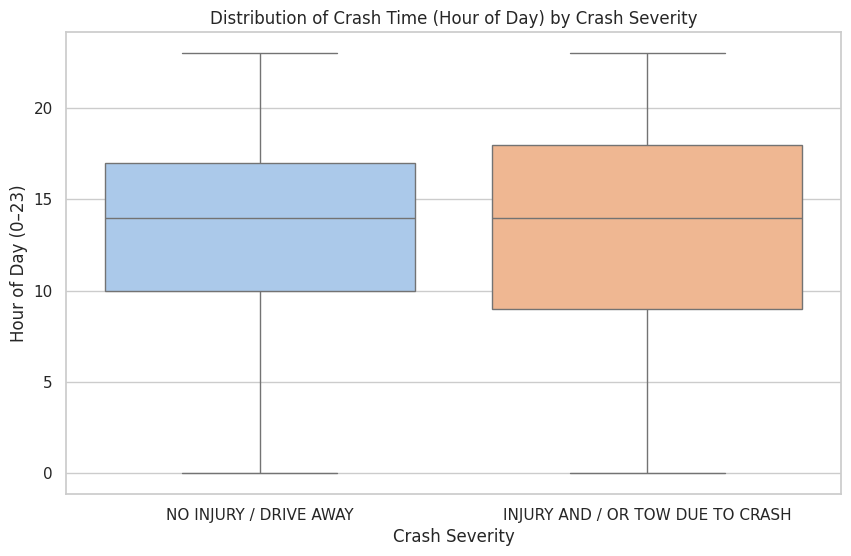

In [7]:
# Outlier Analysis and Data Spread using Boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='crash_type',
    y='crash_hour',
    palette='pastel'
)

plt.title('Distribution of Crash Time (Hour of Day) by Crash Severity')
plt.xlabel('Crash Severity')
plt.ylabel('Hour of Day (0–23)')
plt.show()




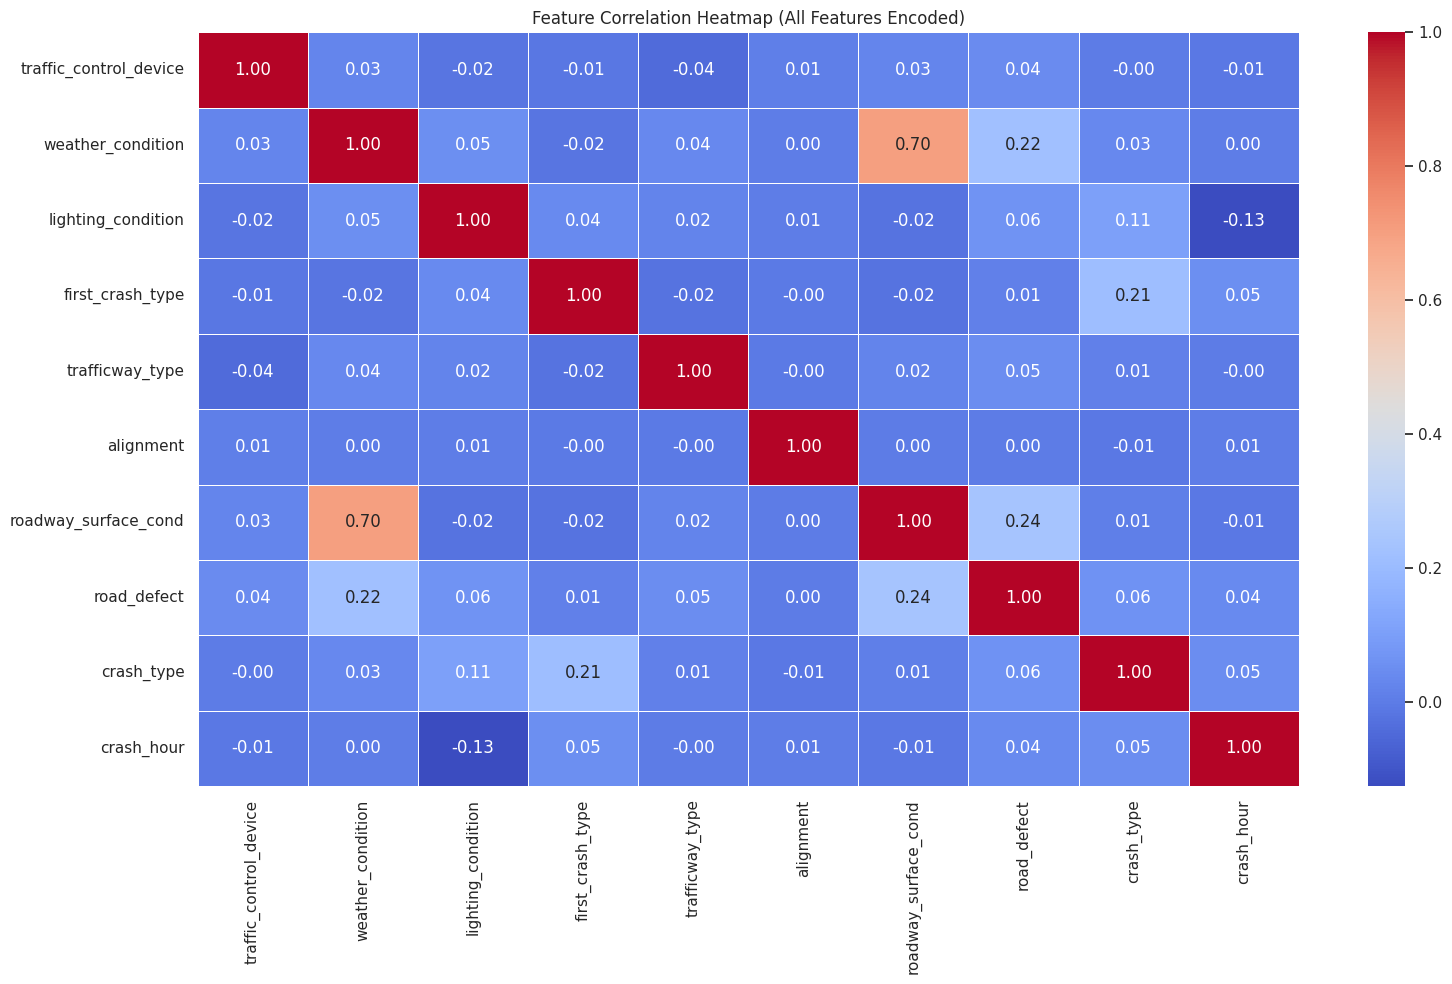

In [8]:
# Correlation Heatmap
# Create a copy of the dataframe
df_encoded = df.copy()

# Initialize LabelEncoder
le = LabelEncoder()

# Encode all string/object columns into numeric integers
for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    # Convert column to string to handle potential NaN values cleanly
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# If crash_date exists and isn't numeric, you can drop it or extract datetime components
if 'crash_date' in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=['crash_date'])

# Plot correlation heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(df_encoded.corr(), cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap (All Features Encoded)")
plt.tight_layout()
plt.show()
